# Exploratory Data Analysis

This notebook performs a comprehensive exploratory analysis of the cleaned Indian Job Market dataset. 

### Research Questions

This exploratory analysis aims to answer the following key questions:

1. What are the overall salary trends in the Indian job market?
2. Which companies are hiring the most, and which offer the highest salaries?
3. Which locations provide the greatest employment opportunities and compensation?
4. Which technical and professional skills are currently most in demand?
5. What experience levels are employers primarily seeking?
6. How are salary, experience, company ratings, and reviews related?
7. What actionable insights can help students and job seekers make informed career decisions?

### Import Required Libraries

In [61]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px


In [62]:
import plotly
import plotly.io as pio

### Load Cleaned Dataset

In [63]:
df = pd.read_csv("../data/processed/cleaned_job_market.csv")

In [64]:
### Project Theme

# Primary Color Palette
PRIMARY = "#6D28D9"      # Deep Violet
SECONDARY = "#8B5CF6"    # Violet
ACCENT = "#A78BFA"       # Lavender

PINK = "#EC4899"
MAGENTA = "#D946EF"
INDIGO = "#4F46E5"
CYAN = "#06B6D4"

# Semantic Colors
SUCCESS = "#22C55E"
WARNING = "#F59E0B"
DANGER = "#EF4444"

# Text & Layout
TEXT = "#0F172A"
MUTED = "#64748B"

GRID = "#E2E8F0"

FONT = "Arial"

In [65]:
def style_plot(fig):

    fig.update_layout(

        template="plotly",

        font=dict(
            family=FONT,
            size=13,
            color=TEXT
        ),

        title=dict(
            x=0.5,
            xanchor="center",
            font=dict(
                size=20,
                family=FONT
            )
        ),

        margin=dict(
            l=40,
            r=40,
            t=65,
            b=35
        ),

        hovermode="x unified",

        legend=dict(
            bgcolor="rgba(0,0,0,0)",
            borderwidth=0
        )
    )

    fig.update_xaxes(
        showgrid=False,
        zeroline=False,
        showline=False
    )

    fig.update_yaxes(
        showgrid=True,
        gridcolor=GRID,
        griddash="dot",
        gridwidth=0.8,
        zeroline=False,
        showline=False
    )

    return fig

### Salary Analysis

In [66]:
### Salary Dataset

salary_df = df[
    (df["averageSalary"] > 0) &
    (df["averageSalary"] <= df["averageSalary"].quantile(0.99))
].copy()

#### Chart 1. Salary Distribution

In [67]:
fig = px.histogram(
    salary_df,
    x="averageSalary",
    nbins=35,
    title="Distribution of Average Salaries",
    opacity=0.88,
    color_discrete_sequence=[PRIMARY]
)

# Salary axis in Lakhs
max_salary = salary_df["averageSalary"].max()

tick_step = 500000
tick_vals = np.arange(0, max_salary + tick_step, tick_step)
tick_text = [f"₹{int(x/100000)}L" for x in tick_vals]

fig.update_xaxes(
    title="Average Salary (INR)",
    tickmode="array",
    tickvals=tick_vals,
    ticktext=tick_text
)

fig.update_yaxes(
    title="Number of Job Postings"
)

fig.update_traces(
    marker=dict(
        line=dict(
            color="rgba(255,255,255,0.35)",
            width=0.7
        )
    ),
    hovertemplate=(
        "<b>Average Salary</b><br>"
        "₹%{x:,.0f}<br><br>"
        "<b>Job Postings</b><br>"
        "%{y:,}"
        "<extra></extra>"
    )
)

fig = style_plot(fig)

fig.show()

**Insight**

- The salary distribution is positively skewed, indicating that most job opportunities offer salaries within the lower-to-middle compensation range.
- A majority of job postings provide average annual salaries between ₹2 lakh and ₹5 lakh.
- Only a relatively small proportion of positions offer substantially higher salaries, creating a long right tail.
- The distribution suggests that high-paying opportunities exist but represent a niche segment of the overall market.

#### Chart 2. Salary Outlier Analysis

In [68]:
fig = px.box(
    salary_df,
    x="averageSalary",
    title="Average Salary Distribution with Outliers",
    color_discrete_sequence=[SECONDARY],
    points="outliers"
)

# Salary axis in Lakhs
max_salary = salary_df["averageSalary"].max()

tick_step = 500000
tick_vals = np.arange(0, max_salary + tick_step, tick_step)
tick_text = [f"₹{int(x/100000)}L" for x in tick_vals]

fig.update_xaxes(
    title="Average Salary (INR)",
    tickmode="array",
    tickvals=tick_vals,
    ticktext=tick_text
)

fig.update_yaxes(
    title=""
)

fig.update_traces(

    width=0.45,

    marker=dict(
        size=5,
        opacity=0.75,
        line=dict(
            color="white",
            width=0.5
        )
    ),

    line=dict(
        width=2
    ),

    hovertemplate=(
        "<b>Average Salary</b><br>"
        "₹%{x:,.0f}"
        "<extra></extra>"
    )
)

fig = style_plot(fig)

fig.show()

**Insight**

- Most salaries are concentrated within a narrow range, while a limited number of jobs offer exceptionally high compensation.
- Several high-value outliers are visible, confirming the presence of premium-paying positions.
- The positive skew indicates that median salary is a more representative measure than the arithmetic mean.
- Salary variability increases considerably at higher compensation levels.

#### Chart 3: Average Salary by Experience Level

In [69]:
experience_salary = (
    salary_df.groupby("averageExperience")["averageSalary"]
    .mean()
    .reset_index()
    .sort_values("averageExperience")
)

fig = px.line(
    experience_salary,
    x="averageExperience",
    y="averageSalary",
    title="Average Salary by Experience Level",
    markers=True,
    color_discrete_sequence=[CYAN]
)

# Salary axis in Lakhs
max_salary = experience_salary["averageSalary"].max()

tick_step = 500000
tick_vals = np.arange(0, max_salary + tick_step, tick_step)
tick_text = [f"₹{int(x/100000)}L" for x in tick_vals]

fig.update_xaxes(
    title="Average Experience (Years)"
)

fig.update_yaxes(
    title="Average Salary (INR)",
    tickmode="array",
    tickvals=tick_vals,
    ticktext=tick_text
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(
        size=8,
        line=dict(
            color="white",
            width=1
        )
    ),
    hovertemplate=(
        "<b>Experience</b><br>"
        "%{x:.1f} Years<br><br>"
        "<b>Average Salary</b><br>"
        "₹%{y:,.0f}"
        "<extra></extra>"
    )
)

fig = style_plot(fig)

fig.show()

**Insight**

- Salary increases consistently with professional experience, demonstrating a clear positive relationship.
- The largest salary growth occurs after candidates move beyond entry-level positions.
- Early-career salaries remain relatively compressed, while senior positions show greater earning potential.
- Experience continues to be one of the strongest factors influencing compensation.

### Location Analysis

#### Chart 4: Top 10 Hiring Locations

In [70]:
location_share = (
    df["location"]
    .value_counts()
    .head(8)
)

fig = px.pie(
    values=location_share.values,
    names=location_share.index,
    title="Hiring Share by Top Locations",
    hole=0.42,
    color_discrete_sequence=[
        "#312E81",
        "#4338CA",
        "#4F46E5",
        "#6366F1",
        "#818CF8",
        "#A5B4FC",
        "#C7D2FE",
        "#E0E7FF"
    ]
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    textfont=dict(
        size=11,
        color="white"
    ),
    marker=dict(
        line=dict(
            color="white",
            width=2
        )
    ),
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Job Postings: %{value:,}<br>"
        "Share: %{percent}"
        "<extra></extra>"
    )
)

fig = style_plot(fig)

fig.show()

**Insight**

- Bengaluru accounts for the largest share of job postings, reaffirming its position as India's leading technology hub.
- Hyderabad, Pune, Chennai and Mumbai collectively contribute a significant proportion of total hiring activity.
- Employment opportunities remain heavily concentrated in metropolitan cities with mature IT ecosystems.
- Regional hiring patterns highlight the dominance of established technology and business centers.

### Job Role Analysis

#### Chart 5: Most In-Demand Job Titles

In [71]:
top_jobs = (
    df["title"]
    .dropna()
    .str.strip()
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

fig = px.bar(
    x=top_jobs.values,
    y=top_jobs.index,
    orientation="h",
    title="Top 10 Most In-Demand Job Titles",
    text=top_jobs.values,
    color=top_jobs.values,
    color_continuous_scale=[
        "#F3E8FF",
        "#E9D5FF",
        "#D8B4FE",
        "#C084FC",
        "#A855F7",
        "#9333EA",
        "#7E22CE",
        "#6B21A8",
        "#581C87"
    ]
)

fig.update_coloraxes(showscale=False)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    marker=dict(
        line=dict(
            color="white",
            width=0.8
        )
    ),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Job Postings: %{x:,}"
        "<extra></extra>"
    )
)

fig.update_xaxes(
    title="Number of Job Postings"
)

fig.update_yaxes(
    title="Job Title"
)

fig = style_plot(fig)

fig.show()

**Insight**

- Software engineering and development roles dominate hiring across the dataset.
- Demand is concentrated around a relatively small group of technical job titles.
- Core software roles continue to generate the highest recruitment activity.
- The hiring landscape reflects sustained demand for software development professionals.

#### Chart 6: Most Heavily Reviewed Companies

In [72]:
company_reviews = (
    df.groupby("companyName", as_index=False)
      .agg(
          ReviewsCount=("ReviewsCount", "mean")
      )
      .sort_values("ReviewsCount", ascending=False)
      .head(15)
)

company_reviews["ReviewsCount"] = pd.to_numeric(
    company_reviews["ReviewsCount"],
    errors="coerce"
)

fig = px.treemap(
    company_reviews,
    path=["companyName"],
    values="ReviewsCount",
    color="ReviewsCount",
    color_continuous_scale=[
        "#EDE9FE",
        "#DDD6FE",
        "#C4B5FD",
        "#A78BFA",
        "#8B5CF6",
        "#7C3AED",
        "#6D28D9"
    ],
    title="Most Heavily Reviewed Companies"
)

fig.update_traces(

    textinfo="label+value",

    marker=dict(
        line=dict(
            color="white",
            width=2
        )
    ),

    hovertemplate=(
        "<b>%{label}</b><br>"
        "Average Reviews: %{value:,.0f}"
        "<extra></extra>"
    )
)

fig.update_coloraxes(
    showscale=False
)

fig = style_plot(fig)

fig.show()

**Insight**

- Large organizations receive substantially more employee reviews than smaller companies.
- Companies such as TCS, Accenture and Infosys demonstrate strong employer visibility due to their large workforce.
- Higher review counts generally indicate more established organizations with greater hiring activity.
- Employer reputation data is considerably richer for large enterprises than for smaller firms.

#### Chart 7: Distribution of Minimum vs Maximum Salaries

In [73]:
fig = px.histogram(
    salary_df,
    x="minimumSalary",
    nbins=35,
    title="Distribution of Minimum and Maximum Salaries",
    opacity=0.65,
    color_discrete_sequence=[PRIMARY]
)

fig.add_histogram(
    x=salary_df["maximumSalary"],
    nbinsx=25,
    name="Maximum Salary",
    marker_color=CYAN,
    opacity=0.55
)

fig.update_traces(
    selector=dict(name="Minimum Salary"),
    name="Minimum Salary"
)

# Salary axis in Lakhs
max_salary = max(
    salary_df["minimumSalary"].max(),
    salary_df["maximumSalary"].max()
)

tick_step = 500000
tick_vals = np.arange(0, max_salary + tick_step, tick_step)
tick_text = [f"₹{int(x/100000)}L" for x in tick_vals]

fig.update_xaxes(
    title="Salary (INR)",
    tickmode="array",
    tickvals=tick_vals,
    ticktext=tick_text
)

fig.update_yaxes(
    title="Number of Job Postings"
)

fig.update_layout(
    barmode="overlay"
)

fig.update_traces(
    marker=dict(
        line=dict(
            color="white",
            width=0.6
        )
    ),
    hovertemplate="<b>%{fullData.name}</b><br>Salary: ₹%{x:,.0f}<br>Job Postings: %{y:,}<extra></extra>"
)

fig.data[0].name = "Minimum Salary"
fig.data[0].showlegend = True

fig = style_plot(fig)

fig.show()

**Insight**

- Maximum salaries exhibit considerably greater variation than minimum salaries.
- Many employers advertise broad salary ranges, reflecting flexibility based on candidate experience and skills.
- Minimum salaries remain relatively concentrated, while upper salary limits vary significantly.
- Wider salary ranges suggest stronger negotiation opportunities for qualified candidates.

### Skill Analysis

#### Chart 8: Most Frequently Demanded Skills

In [74]:
skills = (
    df["tagsAndSkills"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_skills = (
    skills.value_counts()
    .head(15)
    .sort_values(ascending=False)
)

fig = px.bar(
    x=top_skills.index,
    y=top_skills.values,
    title="Most Frequently Demanded Skills",
    text=top_skills.values,
    color=top_skills.values,
    color_continuous_scale=[
        "#FCE7F3",
        "#FBCFE8",
        "#F9A8D4",
        "#F472B6",
        "#EC4899",
        "#DB2777",
        "#BE185D"
    ]
)

fig.update_coloraxes(showscale=False)

fig.update_xaxes(
    title="Skill",
    tickangle=40
)

fig.update_yaxes(
    title="Number of Job Postings"
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    marker=dict(
        line=dict(
            color="white",
            width=0.8
        )
    ),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Job Postings: %{y:,}"
        "<extra></extra>"
    )
)

fig = style_plot(fig)

fig.show()

**Insights**

- Sales and management-related skills dominate the dataset, reflecting strong demand across multiple industries.
- Python is the highest-ranked technical skill, followed by CSS, SAP, SQL, Java, and C#.
- Both technical and communication skills appear among the top requirements, indicating employers value a balanced skill set.
- A small group of core skills accounts for a significant share of total job postings.

#### Chart 9: Highest Paying Skills

In [75]:
skill_salary = (
    df[
        (df["maximumSalary"] > 0) &
        (df["tagsAndSkills"].notna())
    ][["tagsAndSkills", "maximumSalary"]]
    .copy()
)

skill_salary["tagsAndSkills"] = skill_salary["tagsAndSkills"].str.split(",")

skill_salary = skill_salary.explode("tagsAndSkills")

skill_salary["tagsAndSkills"] = (
    skill_salary["tagsAndSkills"]
    .str.strip()
)

skill_salary = (
    skill_salary.groupby("tagsAndSkills", as_index=False)
    .agg(
        medianSalary=("maximumSalary", "median"),
        jobs=("tagsAndSkills", "count")
    )
)

skill_salary = skill_salary[
    skill_salary["jobs"] >= 20
]

skill_salary = (
    skill_salary
    .sort_values("medianSalary", ascending=False)
    .head(15)
    .sort_values("medianSalary")
)

skill_salary["SalaryLabel"] = (
    "₹" + (skill_salary["medianSalary"] / 100000).round(1).astype(str) + "L"
)

fig = px.bar(
    skill_salary,
    x="medianSalary",
    y="tagsAndSkills",
    orientation="h",
    text="SalaryLabel",
    color="medianSalary",
    color_continuous_scale=[
        "#FCE7F3",
        "#FBCFE8",
        "#F9A8D4",
        "#F472B6",
        "#EC4899",
        "#DB2777",
        "#BE185D"
    ],
    title="Highest Paying Skills"
)

fig.update_coloraxes(showscale=False)

# Salary axis in Lakhs
max_salary = skill_salary["medianSalary"].max()

tick_step = 500000
tick_vals = np.arange(0, max_salary + tick_step, tick_step)
tick_text = [f"₹{int(x/100000)}L" for x in tick_vals]

fig.update_xaxes(
    title="Median Maximum Salary (INR)",
    tickmode="array",
    tickvals=tick_vals,
    ticktext=tick_text
)

fig.update_yaxes(
    title="Skill"
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    marker=dict(
        line=dict(
            color="white",
            width=0.8
        )
    ),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Median Salary: ₹%{x:,.0f}<br>"
        "Job Postings: %{customdata[0]:,}"
        "<extra></extra>"
    ),
    customdata=skill_salary[["jobs"]]
)

fig = style_plot(fig)

fig.show()

**Insights**

- Medical specializations dominate the highest-paying skills, with Interventional Cardiology offering the highest median salary ceiling.
- Specialized healthcare skills consistently command higher salary ceilings than most technical and professional skills.
- Emerging AI skills such as LLMs and PyTorch also appear among the highest-paying skills, reflecting growing demand for advanced AI expertise.
- The chart highlights that niche, specialized skills generally offer significantly higher earning potential than broad, general-purpose competencies.

#### Chart 10: Job Postings vs Experience Level

In [76]:
experience_df = df.copy()

experience_df["ExperienceGroup"] = pd.cut(
    experience_df["averageExperience"],
    bins=[0, 2, 5, 8, 12, 50],
    labels=[
        "0–2 Years",
        "3–5 Years",
        "6–8 Years",
        "9–12 Years",
        "12+ Years"
    ]
)

job_counts = (
    experience_df["ExperienceGroup"]
    .value_counts(sort=False)
    .reset_index()
)

job_counts.columns = [
    "Experience Level",
    "Job Postings"
]

fig = px.bar(
    job_counts,
    x="Experience Level",
    y="Job Postings",
    text="Job Postings",
    color="Job Postings",
    color_continuous_scale=[
        "#ECFEFF",
        "#CFFAFE",
        "#A5F3FC",
        "#67E8F9",
        "#22D3EE",
        "#06B6D4",
        "#0891B2"
    ],
    title="Job Postings by Experience Level"
)

fig.update_coloraxes(
    showscale=False
)

fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    marker=dict(
        line=dict(
            color="white",
            width=0.8
        )
    ),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Job Postings: %{y:,}"
        "<extra></extra>"
    )
)

fig.update_xaxes(
    title="Experience Level"
)

fig.update_yaxes(
    title="Job Postings"
)

fig = style_plot(fig)

fig.show()

**Insight**

- Mid-level experience requirements account for the largest proportion of job postings.
- Entry-level opportunities exist but represent a smaller share of the overall market.
- Demand gradually shifts toward experienced professionals as organizational complexity increases.
- The market currently favors candidates with several years of practical industry experience.

#### Chart 11: Frequently Co-occurring Skills

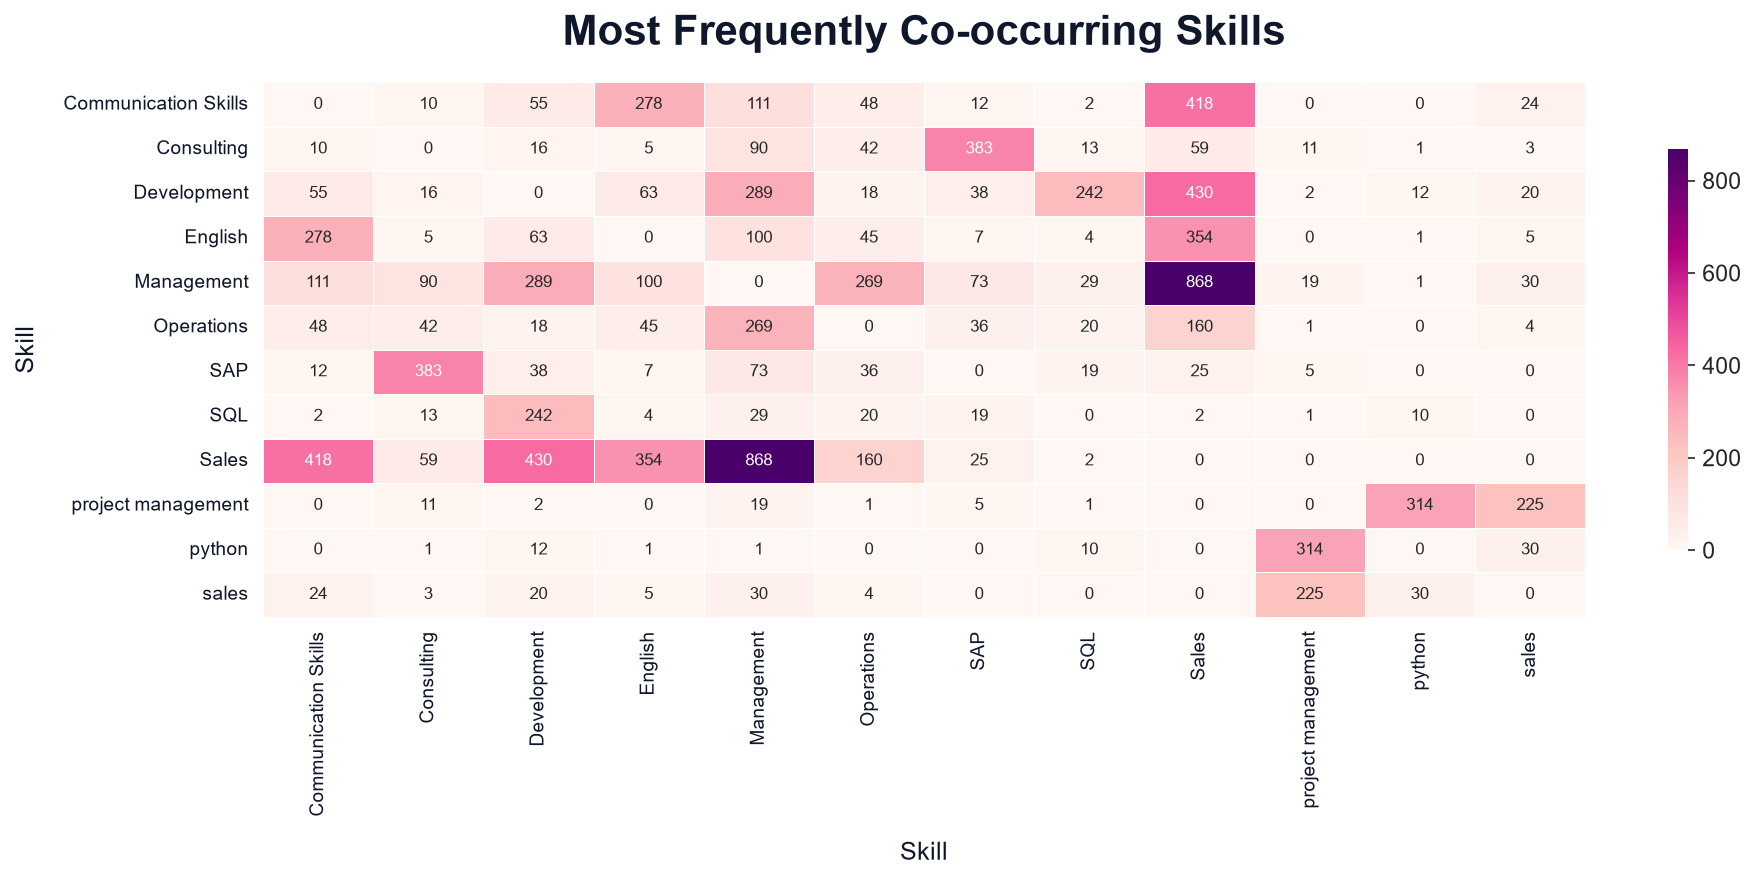

In [77]:
from itertools import combinations

skill_df = (
    df["tagsAndSkills"]
    .dropna()
    .str.split(",")
)

pairs = []

for skills in skill_df:
    skills = list(set([s.strip() for s in skills if s.strip()]))
    pairs.extend(combinations(skills, 2))

pair_df = (
    pd.DataFrame(pairs, columns=["Skill1", "Skill2"])
    .value_counts()
    .reset_index(name="Count")
)

top_skills = (
    pd.concat([pair_df["Skill1"], pair_df["Skill2"]])
    .value_counts()
    .head(12)
    .index
)

pair_df = pair_df[
    pair_df["Skill1"].isin(top_skills) &
    pair_df["Skill2"].isin(top_skills)
]

co_matrix = pd.pivot_table(
    pair_df,
    values="Count",
    index="Skill1",
    columns="Skill2",
    fill_value=0
)

co_matrix = co_matrix.add(co_matrix.T, fill_value=0)

for skill in co_matrix.index:
    co_matrix.loc[skill, skill] = 0

fig, ax = plt.subplots(figsize=(13, 6), dpi=150)

sns.heatmap(
    co_matrix,
    cmap="RdPu",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8},
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"shrink": 0.75},
    square=False,
    ax=ax
)

ax.set_title(
    "Most Frequently Co-occurring Skills",
    fontsize=20,
    fontweight="bold",
    pad=18,
    color=TEXT
)

ax.set_xlabel(
    "Skill",
    fontsize=12,
    labelpad=12,
    color=TEXT
)

ax.set_ylabel(
    "Skill",
    fontsize=12,
    labelpad=12,
    color=TEXT
)

ax.tick_params(
    axis="both",
    labelsize=9,
    colors=TEXT
)

plt.tight_layout()
plt.show()

**Insights**

- Several technologies consistently appear together, indicating common technology stacks used in industry.
- Backend, frontend, cloud and database technologies frequently form tightly connected clusters.
- Learning complementary technologies is likely to increase employability more than mastering isolated skills.
- The network highlights practical learning paths based on real hiring patterns rather than individual technologies alone.

### Company Analysis

#### Chart 12: Market Share of Jobs by Company Size

In [78]:
company_jobs = (
    df.groupby("companyName")
      .agg(
          JobPostings=("companyName", "count"),
          Reviews=("ReviewsCount", "mean")
      )
      .reset_index()
)

company_jobs["Company Size"] = np.where(
    company_jobs["Reviews"] >= company_jobs["Reviews"].median(),
    "Large Companies",
    "Smaller Companies"
)

market_share = (
    company_jobs.groupby("Company Size")["JobPostings"]
    .sum()
    .reset_index()
)

fig = px.pie(
    market_share,
    names="Company Size",
    values="JobPostings",
    hole=0.55,
    color="Company Size",
    color_discrete_map={
        "Large Companies": INDIGO,
        "Smaller Companies": ACCENT
    },
    title="Market Share of Job Postings"
)

fig.update_traces(

    textposition="inside",

    textinfo="percent+label",

    marker=dict(
        line=dict(
            color="white",
            width=2
        )
    ),

    hovertemplate=(
        "<b>%{label}</b><br>"
        "Job Postings: %{value:,}<br>"
        "Market Share: %{percent}"
        "<extra></extra>"
    )
)

fig = style_plot(fig)

fig.show()

**Insights**

- Larger organizations contribute a substantial proportion of total job postings, demonstrating their continued dominance in the hiring market.
- Smaller companies collectively represent a meaningful share of employment opportunities, despite posting fewer jobs individually.
- The Indian technology job market maintains a healthy balance between established enterprises and emerging businesses.
- Job seekers should consider both segments, as large firms provide hiring volume while smaller companies often offer specialized roles and faster career growth.

### Job Market Analysis

#### Chart 13: Salary Range Spread by Job Title

In [79]:
salary_range = (
    df[
        (df["minimumSalary"] > 0) &
        (df["maximumSalary"] > 0)
    ]
    .groupby("title", as_index=False)
    .agg(
        MinSalary=("minimumSalary", "median"),
        MaxSalary=("maximumSalary", "median"),
        Jobs=("title", "count")
    )
)

salary_range = (
    salary_range[salary_range["Jobs"] >= 20]
    .sort_values("MaxSalary", ascending=False)
    .head(12)
    .sort_values("MinSalary")
)

fig = go.Figure()

# Connecting line
fig.add_trace(
    go.Scatter(
        x=salary_range["MinSalary"],
        y=salary_range["title"],
        mode="lines",
        line=dict(
            color=MUTED,
            width=3
        ),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Draw one connector for each job title
for _, row in salary_range.iterrows():
    fig.add_shape(
        type="line",
        x0=row["MinSalary"],
        x1=row["MaxSalary"],
        y0=row["title"],
        y1=row["title"],
        line=dict(
            color=MUTED,
            width=3
        )
    )

# Minimum Salary
fig.add_trace(
    go.Scatter(
        x=salary_range["MinSalary"],
        y=salary_range["title"],
        mode="markers",
        name="Minimum Salary",
        marker=dict(
            size=11,
            color=PRIMARY,
            line=dict(
                color="white",
                width=1
            )
        ),
        hovertemplate=
        "<b>%{y}</b><br>"
        "Minimum Salary: ₹%{x:,.0f}"
        "<extra></extra>"
    )
)

# Maximum Salary
fig.add_trace(
    go.Scatter(
        x=salary_range["MaxSalary"],
        y=salary_range["title"],
        mode="markers",
        name="Maximum Salary",
        marker=dict(
            size=11,
            color=CYAN,
            line=dict(
                color="white",
                width=1
            )
        ),
        hovertemplate=
        "<b>%{y}</b><br>"
        "Maximum Salary: ₹%{x:,.0f}"
        "<extra></extra>"
    )
)

# Salary axis in Lakhs
max_salary = salary_range["MaxSalary"].max()

tick_step = 500000
tick_vals = np.arange(0, max_salary + tick_step, tick_step)
tick_text = [f"₹{int(x/100000)}L" for x in tick_vals]

fig.update_xaxes(
    title="Salary (INR)",
    tickmode="array",
    tickvals=tick_vals,
    ticktext=tick_text
)

fig.update_yaxes(
    title="Job Title"
)

fig.update_layout(
    title="Salary Range Spread by Job Title"
)

fig = style_plot(fig)

fig.show()

**Insights**

- Solution Architect roles offer both the highest minimum salaries and the highest salary ceilings, indicating strong earning potential.
- Senior data and software engineering roles generally provide wider salary ranges than entry-level developer positions.
- Roles with larger salary spreads suggest greater scope for salary negotiation based on experience and expertise.
- Specialized architecture and senior engineering positions consistently command higher compensation than general development roles.

#### Chart 14: Location vs. Skill Matrix

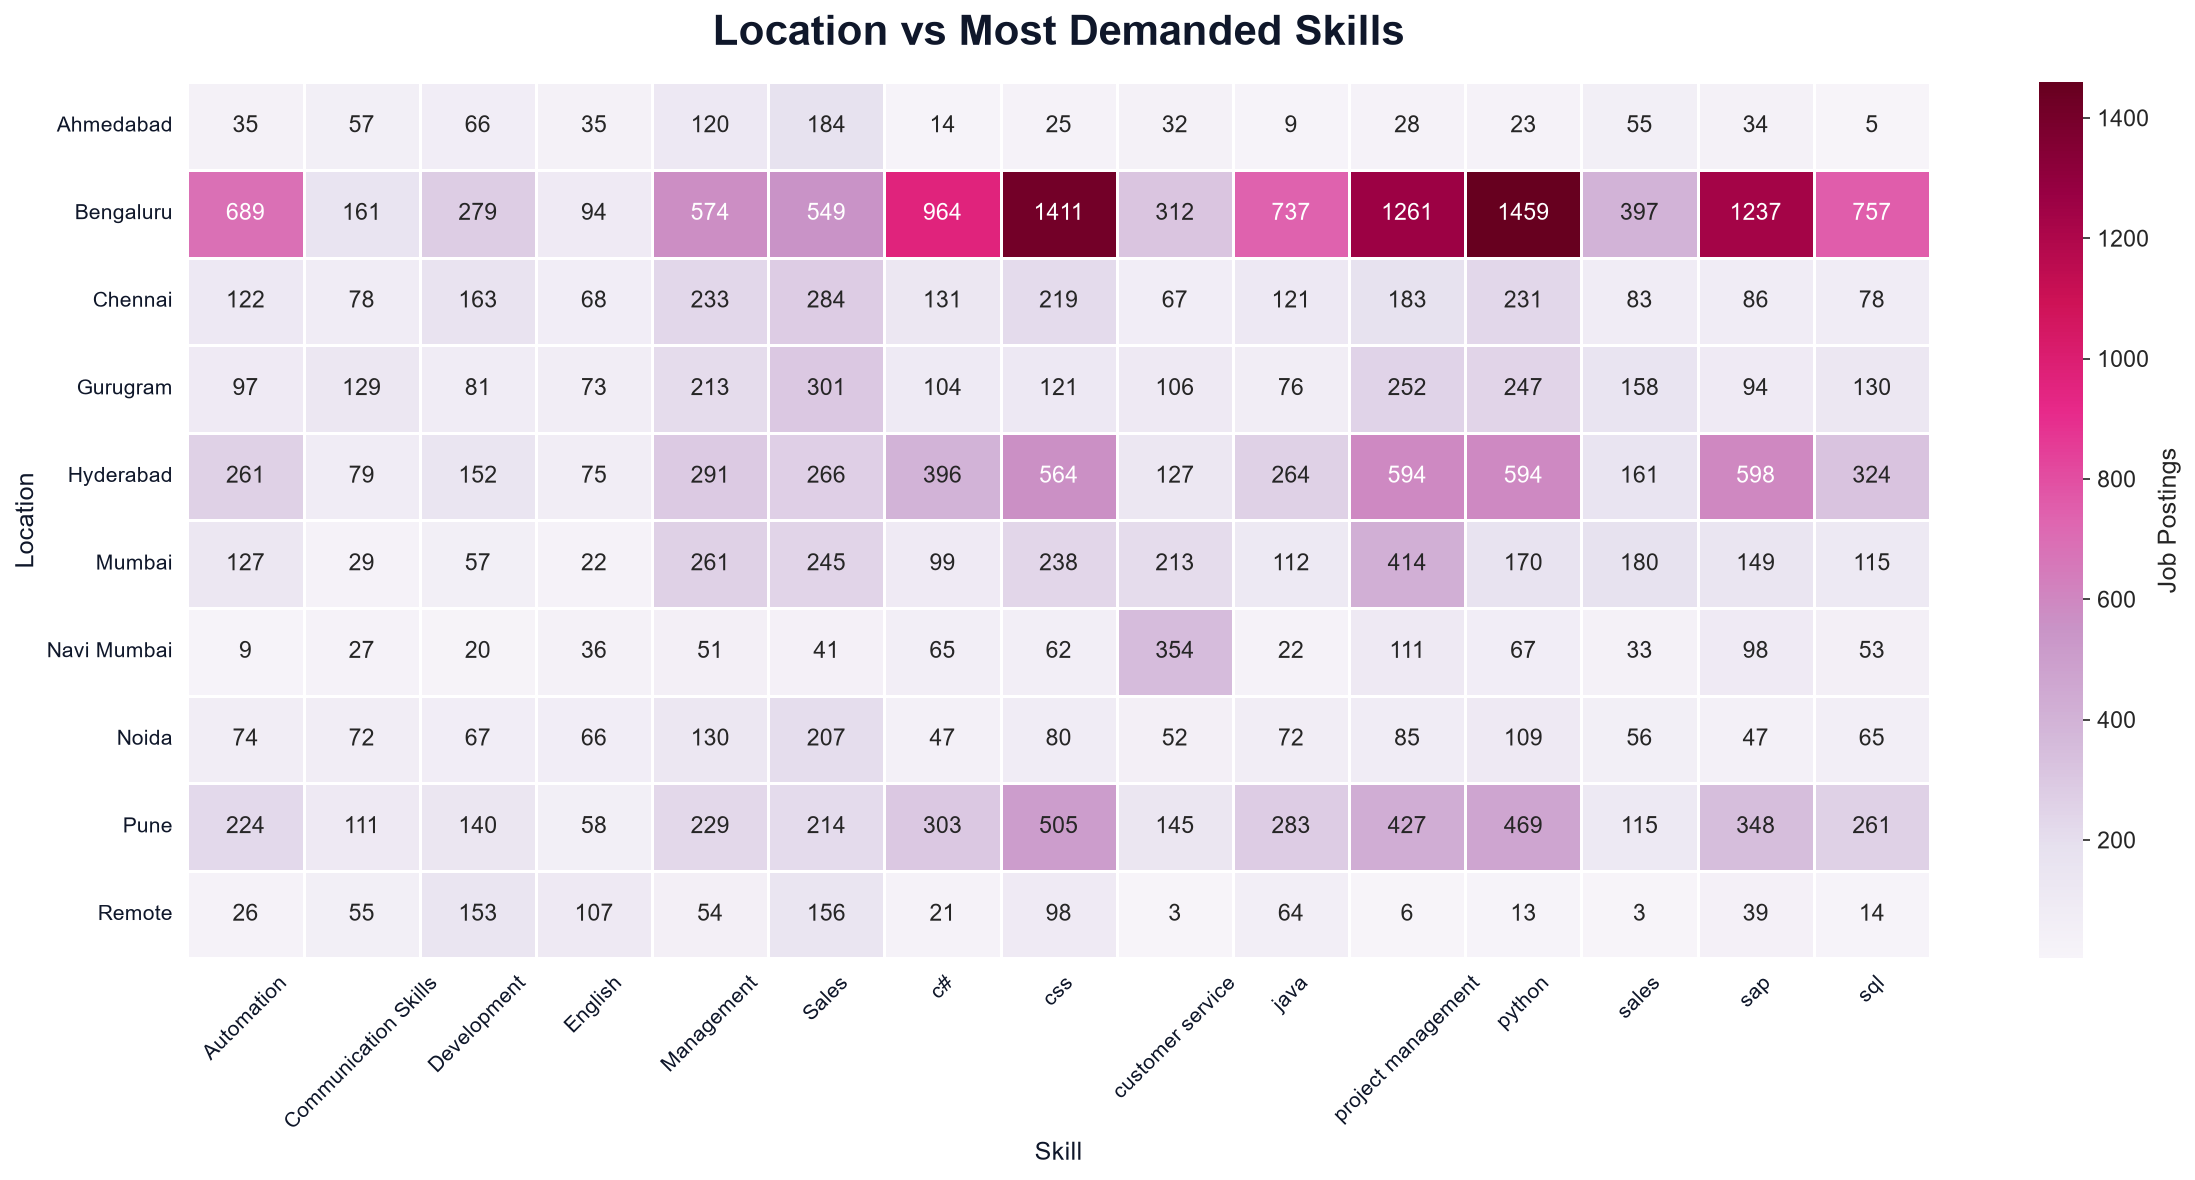

In [80]:
skills_df = df[["location", "tagsAndSkills"]].copy()

skills_df = skills_df.dropna()

skills_df["tagsAndSkills"] = (
    skills_df["tagsAndSkills"]
    .astype(str)
    .str.split(",")
)

skills_df = skills_df.explode("tagsAndSkills")

skills_df["tagsAndSkills"] = (
    skills_df["tagsAndSkills"]
    .astype(str)
    .str.strip()
)

skills_df = skills_df[
    skills_df["tagsAndSkills"] != ""
]

top_locations = (
    skills_df["location"]
    .value_counts()
    .head(10)
    .index
)

top_skills = (
    skills_df["tagsAndSkills"]
    .value_counts()
    .head(15)
    .index
)

filtered_skills = skills_df[
    skills_df["location"].isin(top_locations) &
    skills_df["tagsAndSkills"].isin(top_skills)
]

heatmap_data = (
    filtered_skills
    .groupby(["location", "tagsAndSkills"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 8), dpi=150)

sns.heatmap(
    heatmap_data,
    cmap="PuRd",          # Theme color
    annot=True,
    fmt="d",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Job Postings"},
    ax=ax
)

ax.set_title(
    "Location vs Most Demanded Skills",
    fontsize=20,
    fontweight="bold",
    pad=18,
    color=TEXT
)

ax.set_xlabel(
    "Skill",
    fontsize=12,
    color=TEXT
)

ax.set_ylabel(
    "Location",
    fontsize=12,
    color=TEXT
)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=10,
    colors=TEXT
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=10,
    colors=TEXT
)

plt.tight_layout()
plt.show()

**Insights**

- Major technology hubs exhibit the widest variety of technical skills demanded by employers.
- Certain cities demonstrate specialization in specific technologies, reflecting regional industry ecosystems.
- Metropolitan areas consistently advertise a broader technology stack than smaller cities.
- The heatmap highlights regional demand patterns that can help job seekers align skill development with preferred work locations.

#### Chart 15: Experience vs. Salary Ceiling

In [81]:
experience_salary = df[
    (df["maximumSalary"] > 0)
].copy()

experience_salary["maximumSalaryLakhs"] = (
    experience_salary["maximumSalary"] / 100000
)

experience_salary["Experience Bracket"] = pd.cut(
    experience_salary["averageExperience"],
    bins=[0, 2, 5, 8, 12, 50],
    labels=[
        "0–2 Years",
        "3–5 Years",
        "6–8 Years",
        "9–12 Years",
        "12+ Years"
    ],
    include_lowest=True
)

fig = px.box(
    experience_salary,
    x="Experience Bracket",
    y="maximumSalaryLakhs",
    color="Experience Bracket",
    category_orders={
        "Experience Bracket": [
            "0–2 Years",
            "3–5 Years",
            "6–8 Years",
            "9–12 Years",
            "12+ Years"
        ]
    },
    color_discrete_sequence=[
        "#CFFAFE",
        "#A5F3FC",
        "#67E8F9",
        "#22D3EE",
        "#0891B2"
    ],
    points=False,
    title="Salary Distribution Across Experience Levels"
)

fig.update_traces(
    line=dict(width=2),
    marker=dict(
        line=dict(
            color="white",
            width=1
        )
    ),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Maximum Salary: ₹%{y:.1f}L"
        "<extra></extra>"
    )
)

fig.update_xaxes(
    title="Experience"
)

fig.update_yaxes(
    title="Maximum Salary (Lakhs INR)",
    range=[0, 60]
)

fig.update_layout(
    showlegend=False
)

fig = style_plot(fig)

fig.show()

**Insights**

- Salary ceilings generally increase as experience grows, confirming experience as a major driver of compensation.
- The growth rate becomes less pronounced at higher experience levels, suggesting diminishing salary gains after reaching senior positions.
- Considerable variation exists among professionals with similar experience, indicating that specialization, company, and role also influence salary.
- The regression trend demonstrates a strong positive relationship between experience and earning potential while highlighting substantial market variability.

## Key Findings

- Salary growth shows a clear positive relationship with experience, with compensation increasing more rapidly beyond mid-level roles.

- Hiring activity is concentrated within a small number of metropolitan technology hubs, highlighting strong regional clustering of employment opportunities.

- A limited number of technical skills dominate employer demand, indicating a relatively stable core technology stack across the market.

- Specialized skills command substantially higher salary ceilings despite appearing in fewer job postings, demonstrating the value of technical specialization.

- Large organizations contribute a significant proportion of total hiring, while smaller companies collectively provide considerable employment opportunities across niche domains.

- Frequently co-occurring skills reveal common technology stacks, emphasizing the importance of learning complementary tools rather than isolated technologies.

## Conclusion

This exploratory analysis demonstrates that experience, technical specialization, and geographic concentration are the primary factors shaping the Indian technology job market. While demand remains centered around a core set of technologies, specialized skills offer greater salary potential and complementary skill combinations improve employability. These insights provide a data-driven understanding of current hiring trends and can support informed decisions by students, professionals, recruiters, and educators.